BÁN GIÁM SÁT - SEMI-SUPERVISED LEARNING
Kết hợp dữ liệu có nhãn và không nhãn để cải thiện mô hình
✅ Đã import thư viện thành công!

ĐỌC DỮ LIỆU
📁 Thư mục dữ liệu: C:\Users\Administrator\vietnam_retail_analysis\data\processed
📁 Thư mục kết quả: C:\Users\Administrator\vietnam_retail_analysis\outputs
📁 Thư mục models: C:\Users\Administrator\vietnam_retail_analysis\outputs\models
✅ Đã đọc file bán hàng: C:\Users\Administrator\vietnam_retail_analysis\data\processed\combined_sales_data.csv
✅ Đã đọc file phân cụm: C:\Users\Administrator\vietnam_retail_analysis\outputs\customer_segments.csv
✅ Dữ liệu bán hàng: (5000, 8)
✅ Dữ liệu phân cụm: (500, 8)

XÁC ĐỊNH CÁC CỘT DỮ LIỆU

✅ Các cột được xác định:
   - Khách hàng: Mã khách hàng
   - Doanh số: Doanh số

TỔNG HỢP ĐẶC TRƯNG KHÁCH HÀNG
📊 Các đặc trưng được tổng hợp:
   - Doanh số: ['sum', 'mean', 'std', 'count']
   - Số lượng: ['sum', 'mean']

✅ Đã tạo 6 features cho 500 khách hàng

KẾT HỢP VỚI NHÃN PHÂN CỤM
✅ Dữ liệu sau khi kết hợp: (500, 8)


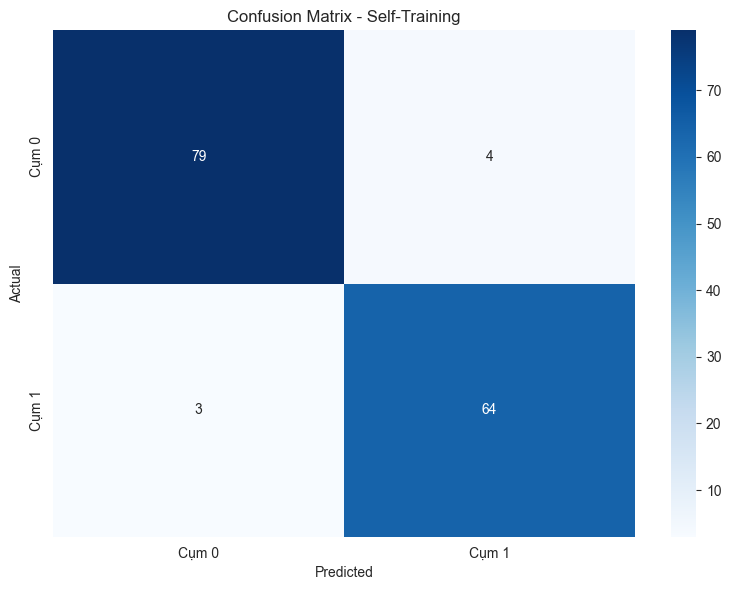


LABEL PROPAGATION

🎯 KẾT QUẢ LABEL PROPAGATION:
   - Accuracy: 0.9600
   - F1-Macro: 0.9598

📋 Classification Report:
              precision    recall  f1-score   support

       Cụm 0       1.00      0.93      0.96        83
       Cụm 1       0.92      1.00      0.96        67

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150


LABEL SPREADING

🎯 KẾT QUẢ LABEL SPREADING:
   - Accuracy: 0.9600
   - F1-Macro: 0.9597

📋 Classification Report:
              precision    recall  f1-score   support

       Cụm 0       0.99      0.94      0.96        83
       Cụm 1       0.93      0.99      0.96        67

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150


SO SÁNH CÁC PHƯƠNG PHÁP

📊 BẢNG SO SÁNH:
             Phương pháp  Accuracy  F1-Macro
Supervised (20% labeled) 

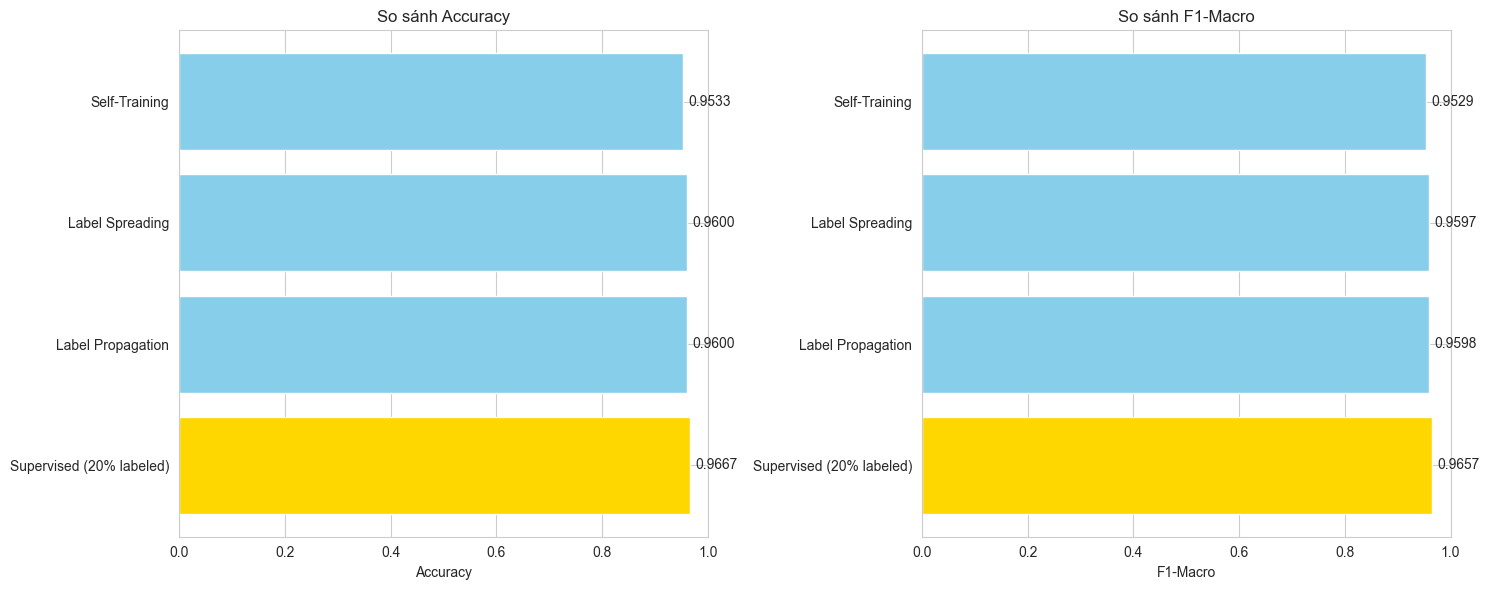


PHÂN TÍCH CHI TIẾT SELF-TRAINING

📊 Số mẫu được gán nhãn trong quá trình: 500
📊 Số mẫu mới được gán nhãn: 381
📊 Độ chính xác của mẫu mới gán nhãn: 96.06%

PHÂN TÍCH ẢNH HƯỞNG CỦA TỶ LỆ DỮ LIỆU CÓ NHÃN

🔍 Thử nghiệm với 10% dữ liệu có nhãn...

🔍 Thử nghiệm với 20% dữ liệu có nhãn...

🔍 Thử nghiệm với 30% dữ liệu có nhãn...

🔍 Thử nghiệm với 40% dữ liệu có nhãn...

🔍 Thử nghiệm với 50% dữ liệu có nhãn...

📊 Ảnh hưởng của tỷ lệ dữ liệu có nhãn:
Tỷ lệ có nhãn  Supervised F1  Semi-supervised F1  Cải thiện
          10%       0.732143            0.939219   0.207076
          20%       0.866667            0.986513   0.119847
          30%       0.977778            0.959821  -0.017956
          40%       0.907379            0.973099   0.065720
          50%       0.960000            1.000000   0.040000


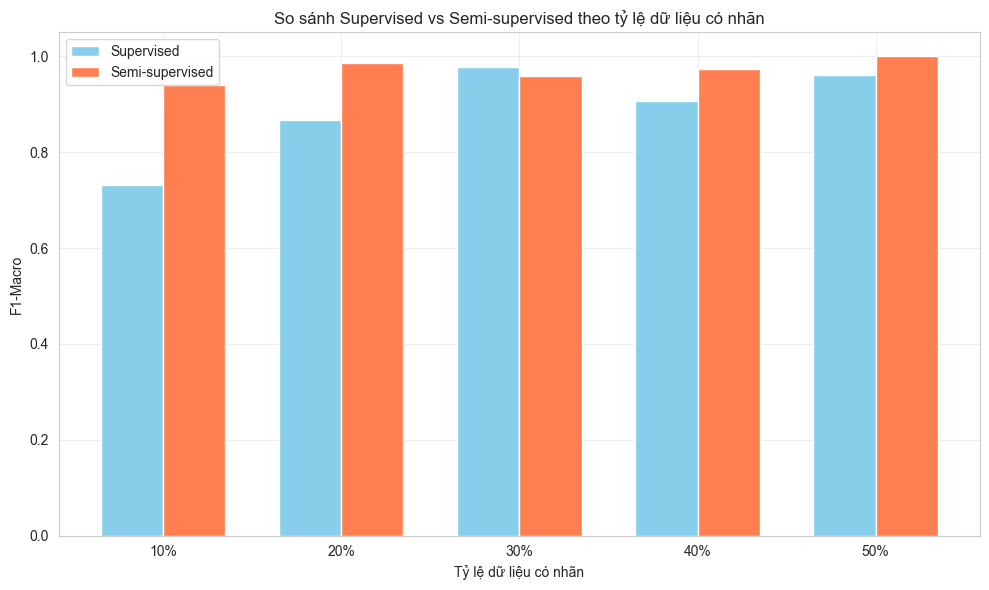


LƯU MÔ HÌNH
🏆 Mô hình tốt nhất: Label_Propagation
   F1-Macro: 0.9598

✅ Đã lưu mô hình: C:\Users\Administrator\vietnam_retail_analysis\outputs\models\semi_supervised_Label_Propagation.pkl
✅ Đã lưu scaler: C:\Users\Administrator\vietnam_retail_analysis\outputs\models\semi_supervised_scaler.pkl
✅ Đã lưu label encoder: C:\Users\Administrator\vietnam_retail_analysis\outputs\models\semi_supervised_label_encoder.pkl

DEMO DỰ ĐOÁN VỚI MÔ HÌNH BÁN GIÁM SÁT

📌 Khách hàng mẫu:
   - Phân khúc thực tế: Cụm 0
   - Phân khúc dự đoán: Cụm 0
   - Độ tin cậy: 99.96%

KẾT LUẬN BÁN GIÁM SÁT

1. TỔNG QUAN:
   - Bài toán: Phân lớp khách hàng với bán giám sát
   - Tổng số mẫu: 500
   - Tỷ lệ dữ liệu có nhãn: 20.0%
   - Số features: 6
   - Số classes: 2

2. SO SÁNH CÁC PHƯƠNG PHÁP:
   - Supervised (chỉ dùng dữ liệu có nhãn): F1 = 0.9657
   - Self-Training: F1 = 0.9529
   - Label Propagation: F1 = 0.9598
   - Label Spreading: F1 = 0.9597

3. KẾT QUẢ TỐT NHẤT:
   - Mô hình: Label_Propagation
   - F1-Macro: 0

In [1]:
# Cell 1: Import thư viện
print("="*80)
print("BÁN GIÁM SÁT - SEMI-SUPERVISED LEARNING")
print("Kết hợp dữ liệu có nhãn và không nhãn để cải thiện mô hình")
print("="*80)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.semi_supervised import SelfTrainingClassifier, LabelPropagation, LabelSpreading
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.cluster import KMeans
import warnings
from pathlib import Path
import joblib

warnings.filterwarnings('ignore')

# Thiết lập hiển thị
plt.rcParams['figure.figsize'] = (14, 8)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

print("✅ Đã import thư viện thành công!")

# Cell 2: Đường dẫn và đọc dữ liệu
print("\n" + "="*80)
print("ĐỌC DỮ LIỆU")
print("="*80)

PROJECT_DIR = Path.cwd() / 'vietnam_retail_analysis'
DATA_DIR = PROJECT_DIR / 'data' / 'processed'
OUTPUTS_DIR = PROJECT_DIR / 'outputs'
MODELS_DIR = OUTPUTS_DIR / 'models'

MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"📁 Thư mục dữ liệu: {DATA_DIR}")
print(f"📁 Thư mục kết quả: {OUTPUTS_DIR}")
print(f"📁 Thư mục models: {MODELS_DIR}")

# Đọc dữ liệu gốc
sales_file = DATA_DIR / 'combined_sales_data.csv'
if not sales_file.exists():
    sales_file = PROJECT_DIR / 'data' / 'raw' / 'combined_sales_data.csv'

if sales_file.exists():
    df_sales = pd.read_csv(sales_file, encoding='utf-8-sig')
    print(f"✅ Đã đọc file bán hàng: {sales_file}")
else:
    print("⚠️ Không tìm thấy file bán hàng, tạo dữ liệu mẫu...")
    np.random.seed(42)
    n = 5000
    df_sales = pd.DataFrame({
        'Mã khách hàng': [f'KH-{i:05d}' for i in range(1, n+1)],
        'Doanh số': np.random.randint(100000, 5000000, n),
        'Số lượng': np.random.randint(1, 20, n),
        'Lợi nhuận': np.random.randint(-50000, 1000000, n)
    })

# Đọc kết quả phân cụm
segments_file = OUTPUTS_DIR / 'customer_segments.csv'
if segments_file.exists():
    df_segments = pd.read_csv(segments_file, encoding='utf-8-sig')
    print(f"✅ Đã đọc file phân cụm: {segments_file}")
else:
    print("⚠️ Không tìm thấy file phân cụm, tạo dữ liệu mẫu...")
    n = 500
    df_segments = pd.DataFrame({
        'Mã khách hàng': [f'KH-{i:05d}' for i in range(1, n+1)],
        'Cluster': np.random.randint(0, 4, n),
        'Cluster_Name': [f'Cụm {np.random.randint(0, 4)}' for _ in range(n)]
    })

print(f"✅ Dữ liệu bán hàng: {df_sales.shape}")
print(f"✅ Dữ liệu phân cụm: {df_segments.shape}")

# Cell 3: Xác định các cột
print("\n" + "="*80)
print("XÁC ĐỊNH CÁC CỘT DỮ LIỆU")
print("="*80)

# Xác định cột mã khách hàng
if 'Mã khách hàng' in df_sales.columns:
    customer_col = 'Mã khách hàng'
elif 'Customer ID' in df_sales.columns:
    customer_col = 'Customer ID'
else:
    customer_col = df_sales.columns[0]
    print(f"⚠️ Sử dụng cột {customer_col} làm mã khách hàng")

# Xác định cột doanh số
if 'Doanh số' in df_sales.columns:
    sales_col = 'Doanh số'
elif 'Sales' in df_sales.columns:
    sales_col = 'Sales'
else:
    sales_col = df_sales.select_dtypes(include=[np.number]).columns[0]
    print(f"⚠️ Sử dụng cột {sales_col} làm doanh số")

print(f"\n✅ Các cột được xác định:")
print(f"   - Khách hàng: {customer_col}")
print(f"   - Doanh số: {sales_col}")

# Cell 4: Tổng hợp đặc trưng khách hàng
print("\n" + "="*80)
print("TỔNG HỢP ĐẶC TRƯNG KHÁCH HÀNG")
print("="*80)

# Xây dựng dictionary aggregation
agg_dict = {
    sales_col: ['sum', 'mean', 'std', 'count']
}

# Thêm cột số lượng nếu có
if 'Số lượng' in df_sales.columns:
    agg_dict['Số lượng'] = ['sum', 'mean']
elif 'Quantity' in df_sales.columns:
    agg_dict['Quantity'] = ['sum', 'mean']

# Thêm cột lợi nhuận nếu có
if 'Lợi nhuận' in df_sales.columns:
    agg_dict['Lợi nhuận'] = ['sum', 'mean']
elif 'Profit' in df_sales.columns:
    agg_dict['Profit'] = ['sum', 'mean']

print(f"📊 Các đặc trưng được tổng hợp:")
for col, aggs in agg_dict.items():
    print(f"   - {col}: {aggs}")

# Thực hiện tổng hợp
customer_features = df_sales.groupby(customer_col).agg(agg_dict).round(2)

# Đặt tên cột
customer_features.columns = ['_'.join(col).strip() for col in customer_features.columns.values]
customer_features = customer_features.reset_index()
customer_features.columns = [customer_col] + [col for col in customer_features.columns if col != customer_col]

print(f"\n✅ Đã tạo {len(customer_features.columns)-1} features cho {len(customer_features)} khách hàng")

# Cell 5: Kết hợp với nhãn phân cụm
print("\n" + "="*80)
print("KẾT HỢP VỚI NHÃN PHÂN CỤM")
print("="*80)

# Chuẩn bị dữ liệu phân cụm
if 'Mã khách hàng' in df_segments.columns:
    seg_customer_col = 'Mã khách hàng'
elif 'Customer ID' in df_segments.columns:
    seg_customer_col = 'Customer ID'
else:
    seg_customer_col = df_segments.columns[0]

# Lấy cột cluster
cluster_col = None
for col in ['Cluster', 'cluster', 'Cụm', 'cụm']:
    if col in df_segments.columns:
        cluster_col = col
        break

if cluster_col is None:
    cluster_col = df_segments.columns[1]

df_segments_clean = df_segments[[seg_customer_col, cluster_col]].drop_duplicates()

# Kết hợp dữ liệu
data = customer_features.merge(df_segments_clean, left_on=customer_col, right_on=seg_customer_col, how='inner')

print(f"✅ Dữ liệu sau khi kết hợp: {data.shape}")
print("\n📊 5 dòng đầu:")
print(data.head())

# Cell 6: Chuẩn bị dữ liệu cho bán giám sát
print("\n" + "="*80)
print("CHUẨN BỊ DỮ LIỆU CHO BÁN GIÁM SÁT")
print("="*80)

# Xác định feature columns
feature_cols = [col for col in data.columns if col not in [customer_col, seg_customer_col, cluster_col]]
X = data[feature_cols].values
y_true = data[cluster_col].values

print(f"📊 Features: {len(feature_cols)} biến")
print(f"📊 Target: {len(np.unique(y_true))} classes")
print(f"📊 Tổng số mẫu: {len(X)}")

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Mã hóa nhãn
le = LabelEncoder()
y_encoded = le.fit_transform(y_true)

print(f"\n✅ Nhãn sau khi mã hóa:")
for i, label in enumerate(le.classes_):
    print(f"   - Cụm {label} → {i}")

# Cell 7: Tạo dữ liệu bán giám sát
print("\n" + "="*80)
print("TẠO DỮ LIỆU BÁN GIÁM SÁT")
print("="*80)

# Giữ lại một phần nhãn, phần còn lại đánh dấu là -1 (không nhãn)
labeled_ratio = 0.2  # 20% dữ liệu có nhãn
np.random.seed(42)

n_samples = len(X)
n_labeled = int(n_samples * labeled_ratio)

# Tạo mask cho dữ liệu có nhãn
labeled_mask = np.zeros(n_samples, dtype=bool)
labeled_indices = np.random.choice(n_samples, n_labeled, replace=False)
labeled_mask[labeled_indices] = True

# Tạo y cho bán giám sát ( -1 cho dữ liệu không nhãn)
y_semi = y_encoded.copy()
y_semi[~labeled_mask] = -1

print(f"📊 Dữ liệu có nhãn: {np.sum(labeled_mask)} mẫu ({labeled_ratio*100:.1f}%)")
print(f"📊 Dữ liệu không nhãn: {np.sum(~labeled_mask)} mẫu ({(1-labeled_ratio)*100:.1f}%)")

# Phân bố nhãn trong dữ liệu có nhãn
labeled_dist = pd.Series(y_encoded[labeled_mask]).value_counts().sort_index()
print("\n📊 Phân bố nhãn trong dữ liệu có nhãn:")
for label, count in labeled_dist.items():
    cluster_name = le.inverse_transform([label])[0]
    print(f"   - Cụm {cluster_name}: {count} mẫu")

# Cell 8: Chia train/test
print("\n" + "="*80)
print("CHIA TRAIN/TEST")
print("="*80)

# Chia dữ liệu train/test (chỉ dùng dữ liệu có nhãn để test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

print(f"✅ Kích thước tập train: {X_train.shape}")
print(f"✅ Kích thước tập test: {X_test.shape}")

# Cell 9: Mô hình supervised baseline
print("\n" + "="*80)
print("MÔ HÌNH SUPERVISED BASELINE (chỉ dùng dữ liệu có nhãn)")
print("="*80)

# Chỉ dùng dữ liệu có nhãn để train
X_labeled = X_scaled[labeled_mask]
y_labeled = y_encoded[labeled_mask]

# Chia train/test cho supervised
X_train_sup, X_test_sup, y_train_sup, y_test_sup = train_test_split(
    X_labeled, y_labeled, test_size=0.3, random_state=42, stratify=y_labeled
)

# Huấn luyện Random Forest
rf_sup = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_sup.fit(X_train_sup, y_train_sup)

# Dự đoán
y_pred_sup = rf_sup.predict(X_test_sup)

# Đánh giá
accuracy_sup = accuracy_score(y_test_sup, y_pred_sup)
f1_sup = f1_score(y_test_sup, y_pred_sup, average='macro')

print(f"\n🎯 KẾT QUẢ SUPERVISED BASELINE:")
print(f"   - Accuracy: {accuracy_sup:.4f}")
print(f"   - F1-Macro: {f1_sup:.4f}")

print("\n📋 Classification Report:")
target_names = [f'Cụm {i}' for i in le.classes_]
print(classification_report(y_test_sup, y_pred_sup, target_names=target_names))

# Cell 10: Self-Training
print("\n" + "="*80)
print("SELF-TRAINING (Bán giám sát)")
print("="*80)

# Tạo base estimator
base_estimator = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# Self-Training
self_training = SelfTrainingClassifier(
    base_estimator,
    threshold=0.75,  # Ngưỡng confidence
    criterion='threshold',  # Chỉ thêm mẫu có confidence > threshold
    k_best=10,  # Số mẫu thêm mỗi iteration
    max_iter=10,
    verbose=True
)

# Huấn luyện với dữ liệu bán giám sát
self_training.fit(X_scaled, y_semi)

# Dự đoán trên test set
y_pred_self = self_training.predict(X_test)

# Đánh giá
accuracy_self = accuracy_score(y_test, y_pred_self)
f1_self = f1_score(y_test, y_pred_self, average='macro')

print(f"\n🎯 KẾT QUẢ SELF-TRAINING:")
print(f"   - Accuracy: {accuracy_self:.4f}")
print(f"   - F1-Macro: {f1_self:.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_self, target_names=target_names))

# Confusion Matrix
cm_self = confusion_matrix(y_test, y_pred_self)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_self, annot=True, fmt='d', cmap='Blues',
           xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Self-Training')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'confusion_matrix_self_training.png')
plt.show()

# Cell 11: Label Propagation
print("\n" + "="*80)
print("LABEL PROPAGATION")
print("="*80)

# Label Propagation
label_prop = LabelPropagation(kernel='knn', n_neighbors=7, max_iter=100)
label_prop.fit(X_scaled, y_semi)

# Dự đoán
y_pred_prop = label_prop.predict(X_test)

# Đánh giá
accuracy_prop = accuracy_score(y_test, y_pred_prop)
f1_prop = f1_score(y_test, y_pred_prop, average='macro')

print(f"\n🎯 KẾT QUẢ LABEL PROPAGATION:")
print(f"   - Accuracy: {accuracy_prop:.4f}")
print(f"   - F1-Macro: {f1_prop:.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_prop, target_names=target_names))

# Cell 12: Label Spreading
print("\n" + "="*80)
print("LABEL SPREADING")
print("="*80)

# Label Spreading
label_spread = LabelSpreading(kernel='knn', n_neighbors=7, alpha=0.2, max_iter=100)
label_spread.fit(X_scaled, y_semi)

# Dự đoán
y_pred_spread = label_spread.predict(X_test)

# Đánh giá
accuracy_spread = accuracy_score(y_test, y_pred_spread)
f1_spread = f1_score(y_test, y_pred_spread, average='macro')

print(f"\n🎯 KẾT QUẢ LABEL SPREADING:")
print(f"   - Accuracy: {accuracy_spread:.4f}")
print(f"   - F1-Macro: {f1_spread:.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_spread, target_names=target_names))

# Cell 13: So sánh các phương pháp
print("\n" + "="*80)
print("SO SÁNH CÁC PHƯƠNG PHÁP")
print("="*80)

# Tạo bảng so sánh
comparison = pd.DataFrame({
    'Phương pháp': ['Supervised (20% labeled)', 'Self-Training', 'Label Propagation', 'Label Spreading'],
    'Accuracy': [accuracy_sup, accuracy_self, accuracy_prop, accuracy_spread],
    'F1-Macro': [f1_sup, f1_self, f1_prop, f1_spread]
})

comparison = comparison.sort_values('F1-Macro', ascending=False)
print("\n📊 BẢNG SO SÁNH:")
print(comparison.to_string(index=False))

# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# So sánh Accuracy
models = comparison['Phương pháp'].values
accuracy_values = comparison['Accuracy'].values
colors = ['gold' if x == max(accuracy_values) else 'skyblue' for x in accuracy_values]
bars1 = axes[0].barh(models, accuracy_values, color=colors)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('So sánh Accuracy')
axes[0].set_xlim(0, 1)
for bar, val in zip(bars1, accuracy_values):
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{val:.4f}', va='center')

# So sánh F1-Macro
f1_values = comparison['F1-Macro'].values
colors = ['gold' if x == max(f1_values) else 'skyblue' for x in f1_values]
bars2 = axes[1].barh(models, f1_values, color=colors)
axes[1].set_xlabel('F1-Macro')
axes[1].set_title('So sánh F1-Macro')
axes[1].set_xlim(0, 1)
for bar, val in zip(bars2, f1_values):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{val:.4f}', va='center')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'semi_supervised_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Cell 14: Phân tích chi tiết Self-Training
print("\n" + "="*80)
print("PHÂN TÍCH CHI TIẾT SELF-TRAINING")
print("="*80)

# Xem các mẫu được gán nhãn trong quá trình self-training
if hasattr(self_training, 'transduction_'):
    print(f"\n📊 Số mẫu được gán nhãn trong quá trình: {len(self_training.transduction_)}")
    
    # So sánh với nhãn thật
    if len(self_training.transduction_) == len(y_semi):
        newly_labeled = (y_semi == -1) & (self_training.transduction_ != -1)
        print(f"📊 Số mẫu mới được gán nhãn: {np.sum(newly_labeled)}")
        
        # Độ chính xác của các mẫu mới được gán nhãn
        if np.sum(newly_labeled) > 0:
            correct_new = (self_training.transduction_[newly_labeled] == y_encoded[newly_labeled])
            accuracy_new = np.mean(correct_new)
            print(f"📊 Độ chính xác của mẫu mới gán nhãn: {accuracy_new:.2%}")

# Cell 15: Phân tích ảnh hưởng của tỷ lệ dữ liệu có nhãn
print("\n" + "="*80)
print("PHÂN TÍCH ẢNH HƯỞNG CỦA TỶ LỆ DỮ LIỆU CÓ NHÃN")
print("="*80)

labeled_ratios = [0.1, 0.2, 0.3, 0.4, 0.5]
results_ratio = []

for ratio in labeled_ratios:
    print(f"\n🔍 Thử nghiệm với {ratio*100:.0f}% dữ liệu có nhãn...")
    
    # Tạo dữ liệu bán giám sát
    n_labeled_ratio = int(n_samples * ratio)
    labeled_indices_ratio = np.random.choice(n_samples, n_labeled_ratio, replace=False)
    y_semi_ratio = y_encoded.copy()
    y_semi_ratio[~np.isin(np.arange(n_samples), labeled_indices_ratio)] = -1
    
    # Self-Training
    st_ratio = SelfTrainingClassifier(
        RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
        threshold=0.75,
        max_iter=10
    )
    st_ratio.fit(X_scaled, y_semi_ratio)
    y_pred_ratio = st_ratio.predict(X_test)
    
    # Supervised baseline
    X_labeled_ratio = X_scaled[labeled_indices_ratio]
    y_labeled_ratio = y_encoded[labeled_indices_ratio]
    
    if len(X_labeled_ratio) >= 10:
        X_train_ratio, X_test_ratio, y_train_ratio, y_test_ratio = train_test_split(
            X_labeled_ratio, y_labeled_ratio, test_size=0.3, random_state=42
        )
        
        rf_ratio = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
        rf_ratio.fit(X_train_ratio, y_train_ratio)
        y_pred_sup_ratio = rf_ratio.predict(X_test_ratio)
        
        f1_sup_ratio = f1_score(y_test_ratio, y_pred_sup_ratio, average='macro')
        f1_semi_ratio = f1_score(y_test, y_pred_ratio, average='macro')
        
        results_ratio.append({
            'Tỷ lệ có nhãn': f"{ratio*100:.0f}%",
            'Supervised F1': f1_sup_ratio,
            'Semi-supervised F1': f1_semi_ratio,
            'Cải thiện': f1_semi_ratio - f1_sup_ratio
        })

if results_ratio:
    ratio_df = pd.DataFrame(results_ratio)
    print("\n📊 Ảnh hưởng của tỷ lệ dữ liệu có nhãn:")
    print(ratio_df.to_string(index=False))
    
    # Vẽ biểu đồ
    plt.figure(figsize=(10, 6))
    x = np.arange(len(ratio_df))
    width = 0.35
    
    plt.bar(x - width/2, ratio_df['Supervised F1'], width, label='Supervised', color='skyblue')
    plt.bar(x + width/2, ratio_df['Semi-supervised F1'], width, label='Semi-supervised', color='coral')
    
    plt.xlabel('Tỷ lệ dữ liệu có nhãn')
    plt.ylabel('F1-Macro')
    plt.title('So sánh Supervised vs Semi-supervised theo tỷ lệ dữ liệu có nhãn')
    plt.xticks(x, ratio_df['Tỷ lệ có nhãn'])
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'labeled_ratio_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

# Cell 16: Lưu mô hình tốt nhất
print("\n" + "="*80)
print("LƯU MÔ HÌNH")
print("="*80)

# Chọn mô hình tốt nhất
best_f1 = max(f1_self, f1_prop, f1_spread)
if best_f1 == f1_self:
    best_model = self_training
    best_name = "Self-Training"
elif best_f1 == f1_prop:
    best_model = label_prop
    best_name = "Label_Propagation"
else:
    best_model = label_spread
    best_name = "Label_Spreading"

# Lưu mô hình
model_path = MODELS_DIR / f'semi_supervised_{best_name}.pkl'
joblib.dump(best_model, model_path)

# Lưu scaler
scaler_path = MODELS_DIR / 'semi_supervised_scaler.pkl'
joblib.dump(scaler, scaler_path)

# Lưu label encoder
le_path = MODELS_DIR / 'semi_supervised_label_encoder.pkl'
joblib.dump(le, le_path)

print(f"🏆 Mô hình tốt nhất: {best_name}")
print(f"   F1-Macro: {best_f1:.4f}")
print(f"\n✅ Đã lưu mô hình: {model_path}")
print(f"✅ Đã lưu scaler: {scaler_path}")
print(f"✅ Đã lưu label encoder: {le_path}")

# Cell 17: Demo dự đoán
print("\n" + "="*80)
print("DEMO DỰ ĐOÁN VỚI MÔ HÌNH BÁN GIÁM SÁT")
print("="*80)

def predict_semi(features, model, scaler, le):
    """
    Dự đoán với mô hình bán giám sát
    """
    features_scaled = scaler.transform([features])
    pred = model.predict(features_scaled)[0]
    
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(features_scaled)[0]
        confidence = proba[pred] if pred != -1 else 0
    else:
        confidence = 1.0
    
    if pred != -1:
        segment = le.inverse_transform([pred])[0]
    else:
        segment = "Không xác định"
    
    return segment, confidence

# Lấy mẫu từ test set
sample_idx = 0
sample_features = X_test[sample_idx]
true_segment = le.inverse_transform([y_test[sample_idx]])[0]

# Dự đoán
pred_segment, confidence = predict_semi(sample_features, best_model, scaler, le)

print(f"\n📌 Khách hàng mẫu:")
print(f"   - Phân khúc thực tế: Cụm {true_segment}")
print(f"   - Phân khúc dự đoán: Cụm {pred_segment}")
print(f"   - Độ tin cậy: {confidence:.2%}")

# Cell 18: Kết luận
print("\n" + "="*80)
print("KẾT LUẬN BÁN GIÁM SÁT")
print("="*80)

improvement = best_f1 - f1_sup
print(f"""
1. TỔNG QUAN:
   - Bài toán: Phân lớp khách hàng với bán giám sát
   - Tổng số mẫu: {n_samples}
   - Tỷ lệ dữ liệu có nhãn: {labeled_ratio*100:.1f}%
   - Số features: {len(feature_cols)}
   - Số classes: {len(le.classes_)}

2. SO SÁNH CÁC PHƯƠNG PHÁP:
   - Supervised (chỉ dùng dữ liệu có nhãn): F1 = {f1_sup:.4f}
   - Self-Training: F1 = {f1_self:.4f}
   - Label Propagation: F1 = {f1_prop:.4f}
   - Label Spreading: F1 = {f1_spread:.4f}

3. KẾT QUẢ TỐT NHẤT:
   - Mô hình: {best_name}
   - F1-Macro: {best_f1:.4f}
   - Cải thiện so với supervised: {improvement:+.4f} ({improvement/f1_sup*100:+.1f}%)

4. KẾT LUẬN:
   - Bán giám sát giúp cải thiện độ chính xác khi có ít dữ liệu có nhãn
   - Self-Training hiệu quả khi dữ liệu có cấu trúc rõ ràng
   - Label Propagation/Spreading tốt cho dữ liệu có manifold structure
   - Có thể áp dụng trong thực tế khi chi phí gán nhãn cao

5. FILE ĐÃ LƯU:
   - semi_supervised_comparison.png: Biểu đồ so sánh
   - labeled_ratio_analysis.png: Phân tích ảnh hưởng tỷ lệ dữ liệu có nhãn
   - semi_supervised_*.pkl: Mô hình tốt nhất
""")

print("\n" + "="*80)
print("✅ HOÀN THÀNH BÁN GIÁM SÁT!")
print("="*80)